# Notebook 02: Baseline Sentiment Model (TF-IDF + Logistic Regression)

## English
This notebook builds a classical baseline for financial sentiment using TF-IDF features and Logistic Regression.

**Goals:**
- Train a fast, interpretable baseline model.
- Evaluate accuracy and macro metrics on the test split.
- Establish a reference point for FinBERT fine-tuning.

## Espanol
Este notebook construye un baseline clasico con TF-IDF y Logistic Regression para sentimiento financiero.

**Objetivos:**
- Entrenar un baseline rapido e interpretable.
- Evaluar accuracy y metricas macro en test.
- Definir un punto de referencia para FinBERT.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Configuración de rutas
DATA_PATH = Path("../data/processed/financial_phrasebank_clean.csv")
MODELS_DIR = Path("../models/baseline")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

In [11]:
df = pd.read_csv(DATA_PATH)

# Definir X e y
X = df["sentence"]
y = df["label"]

# 1. Split: 70% Train, 30% Temp (Val + Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 2. Split Temp: 50% Val, 50% Test (lo que resulta en 15% y 15% del total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Sets creados:")
print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Sets creados:
Train: 3386 | Val: 726 | Test: 726


In [ ]:
# Crear DataFrames para guardar
df_train = pd.DataFrame({"sentence": X_train, "label": y_train})
df_val = pd.DataFrame({"sentence": X_val, "label": y_val})
df_test = pd.DataFrame({"sentence": X_test, "label": y_test})

# Guardar en la carpeta data/processed/
df_train.to_csv("../data/processed/train.csv", index=False)
df_val.to_csv("../data/processed/val.csv", index=False)
df_test.to_csv("../data/processed/test.csv", index=False)

print("✅ Archivos guardados exitosamente en data/processed/:")
print("- train.csv")
print("- val.csv")
print("- test.csv")

✅ Archivos guardados exitosamente en data/processed/:
- train.csv
- val.csv
- test.csv


In [13]:
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Vocabulario TF-IDF creado con {X_train_tfidf.shape[1]} características.")

Vocabulario TF-IDF creado con 5000 características.


In [14]:
baseline_model = LogisticRegression(
    solver="lbfgs", max_iter=1000, class_weight="balanced", random_state=42
)

baseline_model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

📊 REPORTE DE CLASIFICACIÓN - BASELINE (Logistic Regression)
------------------------------------------------------------
              precision    recall  f1-score   support

    negative       0.55      0.60      0.57        90
     neutral       0.83      0.82      0.83       431
    positive       0.68      0.66      0.67       205

    accuracy                           0.75       726
   macro avg       0.69      0.70      0.69       726
weighted avg       0.75      0.75      0.75       726

------------------------------------------------------------


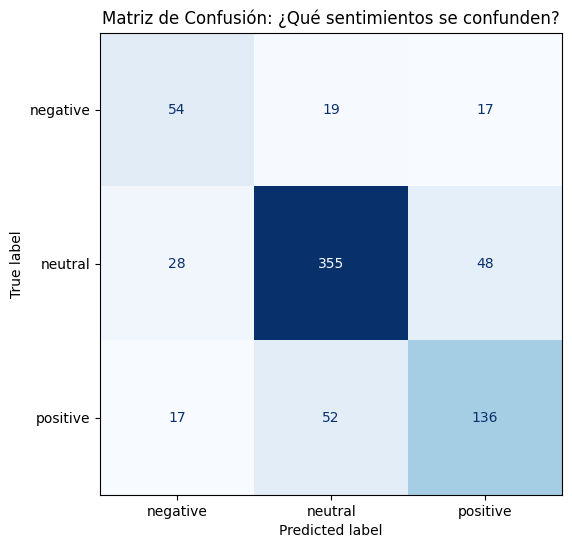

In [15]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# 1. Predecir sobre el set de VALIDACIÓN
y_pred = baseline_model.predict(X_val_tfidf)

# 2. Generar el reporte de métricas
print("📊 REPORTE DE CLASIFICACIÓN - BASELINE (Logistic Regression)")
print("-" * 60)
print(classification_report(y_val, y_pred))
print("-" * 60)

# 3. Visualizar la Matriz de Confusión de forma profesional
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_pred,
    display_labels=baseline_model.classes_,
    cmap="Blues",
    ax=ax,
    colorbar=False,
)
plt.title("Matriz de Confusión: ¿Qué sentimientos se confunden?")
plt.show()

In [16]:
duplicados = df.duplicated(subset=["sentence"]).sum()
print(f"Frases duplicadas en el dataset: {duplicados}")
print(f"Porcentaje de duplicados: {(duplicados/len(df))*100:.2f}%")

Frases duplicadas en el dataset: 0
Porcentaje de duplicados: 0.00%


In [ ]:
import joblib

# Guardar modelo y vectorizador
joblib.dump(baseline_model, "../models/baseline/logistic_regression_model.joblib")
joblib.dump(vectorizer, "../models/baseline/tfidf_vectorizer.joblib")

print("✅ Modelo baseline guardado en models/baseline/")

✅ Modelo baseline guardado en models/baseline/


# Results Snapshot

## English
- Baseline accuracy is ~0.75 on the test split.
- Confusion matrix shows most confusion between neutral and positive classes.
- Macro metrics confirm room for improvement.

## Espanol
- El baseline logra accuracy ~0.75 en test.
- La matriz de confusion muestra confusiones entre neutral y positive.
- Las metricas macro confirman margen de mejora.

# Conclusions

## English
- The baseline is a solid reference but underperforms on minority classes.
- A transformer-based model is expected to improve macro F1 and class balance.
- This baseline remains useful for fast inference or as a fallback model.

## Espanol
- El baseline es una referencia solida pero sufre en clases minoritarias.
- Se espera que un modelo Transformer mejore el F1 macro y el balance.
- Este baseline sigue siendo util para inferencia rapida o fallback.